In [1]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from sklearn.impute import SimpleImputer
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import chi2
from scipy import stats
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
import seaborn as sns
import gseapy as gp

In [19]:
# Load Excel file

file_name = 'organoid_proteomics_log2_Genes_ProteinIds_HQ_LQ.xlsx'
expr_df = pd.read_excel(file_name)
print(expr_df.head())

       Genes Protein.Ids       HQ 1       HQ 2       HQ 3       HQ 4  \
0  IGKV2D-24  A0A075B6R9  15.469740  15.605546  15.871797  16.223689   
1     TRBV18  A0A087X0M5  14.018548  13.719859  14.996434  15.196337   
2      RBM47    A0AV96-2  16.645039  17.192717  16.464375  16.060257   
3      IFT56      A0AVF1  14.486131  14.416633  14.869266  14.594185   
4       UBA6      A0AVT1  16.470419  16.936856  16.731226  16.569620   

        HQ 5       HQ 6       LQ 1       LQ 2       LQ 3       LQ 4  \
0  16.298496  15.688362  16.007540  16.033236  16.145230  16.140013   
1  15.007089  13.414025  14.973182  14.818323  15.131664  15.237176   
2  15.427513  17.282229  16.944746  16.853176  16.812804  16.929894   
3  14.663041  14.434342  14.547919  14.479218  14.505334  14.550176   
4  16.597338  16.799560  16.668026  16.747904  16.630694  16.604197   

        LQ 5       LQ 6       LQ 7       LQ 8       LQ 9      LQ 10  \
0  15.611595  15.097575  15.512410  16.164856  14.729440  15.727059  

  Sample        PC1        PC2 Classification
0   HQ 1  -1.674446 -13.154062   high-quality
1   HQ 2 -17.919659 -17.252291   high-quality
2   HQ 3 -12.442218  -2.176535   high-quality
3   HQ 4  -6.327378  -6.979082   high-quality
4   HQ 5   0.487290 -23.879313   high-quality
[0.4611 0.1669]


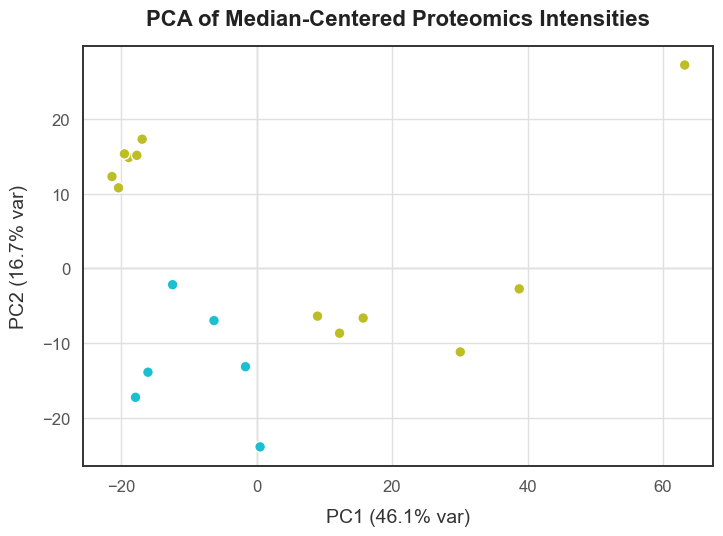

In [20]:
# PCA of proteomics for HQ and LQ organoids (Fig. 5A)

show_labels = False
figure_width = 7.2
figure_height = 5.4
point_size = 60
point_alpha = 0.98
edge_linewidth = 1.0
axis_line_color = '#CFCFCF'
axis_line_width = 1.0
spine_width = 1.4
label_fontsize = 18
tick_fontsize = 15
sample_label_fontsize = 9
text_x_shift = 0.6
text_y_shift = 0.6
output_figure = './Fig 5A.png'

classif_colors = {'high-quality': '#17becf', 'low-quality': '#bcbd22'}

sample_cols = [col_name for col_name in expr_df.columns if str(col_name).startswith('HQ ') or str(col_name).startswith('LQ ')]
X_sample = expr_df[sample_cols].T.copy()
class_labels = pd.Series(['high-quality' if str(col_name).startswith('HQ ') else 'low-quality' for col_name in X_sample.index], index=X_sample.index)

imputer_obj = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer_obj.fit_transform(X_sample), index=X_sample.index, columns=X_sample.columns)
X_centered = X_imputed.sub(X_imputed.median(axis=0), axis=1)

pca_obj = PCA(n_components=2, svd_solver='full')
pca_scores = pca_obj.fit_transform(X_centered)
explained_var = pca_obj.explained_variance_ratio_

plot_df = pd.DataFrame(pca_scores, index=X_sample.index, columns=['PC1', 'PC2']).reset_index().rename(columns={'index': 'Sample'})
plot_df['Classification'] = plot_df['Sample'].map(class_labels)

group_means = plot_df.groupby('Classification')['PC1'].mean()
if group_means.loc['high-quality'] > group_means.loc['low-quality']:
    plot_df['PC1'] = -1 * plot_df['PC1']

print(plot_df.head())
print(np.round(explained_var[:2], 4))

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
ax.set_axisbelow(True)
ax.axhline(0, color=axis_line_color, lw=axis_line_width, zorder=0)
ax.axvline(0, color=axis_line_color, lw=axis_line_width, zorder=0)

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Classification', palette=classif_colors, s=point_size, edgecolor='white', linewidth=edge_linewidth, alpha=point_alpha, zorder=3, ax=ax, legend=False)

if show_labels:
    for _, row_vals in plot_df.iterrows():
        ax.text(row_vals['PC1'] + text_x_shift, row_vals['PC2'] + text_y_shift, row_vals['Sample'], fontsize=sample_label_fontsize, color='black', alpha=0.9)

ax.set_title('PCA of Median-Centered Proteomics Intensities', fontsize=16, fontweight='semibold', color='#222222', pad=15)
ax.set_xlabel('PC1 (' + str(round(explained_var[0] * 100, 1)) + '% var)', fontsize=14, color='#333333', labelpad=10)
ax.set_ylabel('PC2 (' + str(round(explained_var[1] * 100, 1)) + '% var)', fontsize=14, color='#333333', labelpad=10)
ax.tick_params(axis='both', labelsize=12, colors='#555555')
ax.grid(True, color='#E0E0E0')
for spine_name in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine_name].set_linewidth(spine_width)
    ax.spines[spine_name].set_color('#333333')
plt.savefig(output_figure, dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Compute differential abundance on raw values, select top proteins, and save the stats table
sample_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6', 'LQ 1', 'LQ 10', 'LQ 11', 'LQ 12', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9']
hq_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6']
lq_cols = ['LQ 1', 'LQ 10', 'LQ 11', 'LQ 12', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9']
output_stats = 'proteomics_differential_abundance_main_pipeline.xlsx'

sample_df = expr_df[sample_cols].apply(pd.to_numeric, errors='coerce').copy()
gene_vals = expr_df['Genes'].fillna('').astype(str) if 'Genes' in expr_df.columns else pd.Series([''] * len(expr_df), index=expr_df.index)
protein_vals = expr_df['Protein.Ids'].fillna('').astype(str) if 'Protein.Ids' in expr_df.columns else pd.Series(expr_df.index.astype(str), index=expr_df.index)
feature_names = gene_vals.mask(gene_vals.str.strip().eq(''), protein_vals)

rows_out = []
for row_idx in tqdm(sample_df.index, desc='testing proteins'):
    hq_vals = sample_df.loc[row_idx, hq_cols].astype(float)
    lq_vals = sample_df.loc[row_idx, lq_cols].astype(float)
    hq_non_na = hq_vals.notna().sum()
    lq_non_na = lq_vals.notna().sum()
    hq_mean = hq_vals.mean()
    lq_mean = lq_vals.mean()
    log2_fc = hq_mean - lq_mean
    if hq_non_na >= 2 and lq_non_na >= 2:
        pval_val = ttest_ind(hq_vals, lq_vals, equal_var=False, nan_policy='omit').pvalue
    else:
        pval_val = np.nan
    rows_out.append([row_idx, feature_names.loc[row_idx], protein_vals.loc[row_idx], hq_non_na, lq_non_na, hq_mean, lq_mean, log2_fc, pval_val])

stats_df = pd.DataFrame(rows_out, columns=['row_id', 'feature_name', 'protein_ids', 'hq_non_na', 'lq_non_na', 'hq_mean', 'lq_mean', 'log2FC_HQ_minus_LQ', 'pval'])
stats_df['display_name'] = stats_df['feature_name'].fillna('').astype(str)
stats_df['display_name'] = stats_df['display_name'].mask(stats_df['display_name'].str.strip().eq(''), stats_df['protein_ids'])
stats_df['abs_log2FC'] = stats_df['log2FC_HQ_minus_LQ'].abs()
stats_df['passes_presence'] = (stats_df['hq_non_na'] >= 3) & (stats_df['lq_non_na'] >= 6)
valid_mask = stats_df['pval'].notna()
stats_df['padj'] = np.nan
if valid_mask.sum() > 0:
    stats_df.loc[valid_mask, 'padj'] = multipletests(stats_df.loc[valid_mask, 'pval'], method='fdr_bh')[1]
stats_df['is_significant'] = stats_df['passes_presence'] & (stats_df['padj'] < 0.05) & (stats_df['abs_log2FC'] > 1.0)

sig_df = stats_df[stats_df['is_significant']].copy().sort_values(['padj', 'abs_log2FC'], ascending=[True, False])
if sig_df.shape[0] < 154:
    sig_df = stats_df[stats_df['passes_presence']].copy().sort_values(['padj', 'abs_log2FC'], ascending=[True, False]).head(154)
else:
    sig_df = sig_df.head(154)

stats_df.to_excel(output_stats, index=False)
print(stats_df[['display_name', 'log2FC_HQ_minus_LQ', 'pval', 'padj', 'is_significant']].head())
print(sig_df[['display_name', 'log2FC_HQ_minus_LQ', 'pval', 'padj']].head())
print(stats_df['is_significant'].sum())
print(sig_df.shape)
print(output_stats)

testing proteins: 100%|██████████| 7096/7096 [00:18<00:00, 387.96it/s]


  display_name  log2FC_HQ_minus_LQ      pval      padj  is_significant
0    IGKV2D-24            0.092352  0.639182  0.810971           False
1       TRBV18            0.130000  0.755607  0.881521           False
2        RBM47            0.224211  0.537639  0.741479           False
3        IFT56            0.222152  0.049647  0.231134           False
4         UBA6            0.189227  0.065392  0.264522           False
     display_name  log2FC_HQ_minus_LQ          pval      padj
3800        DARS2            0.298828  3.712947e-07  0.002605
6795         NUDC            0.277483  4.439750e-06  0.015572
4571       KLHDC4            0.294867  7.305535e-06  0.017083
3938       ASRGL1            0.670652  2.480015e-05  0.022316
3864        RBMS3           -0.609771  3.444535e-05  0.022316
16
(154, 14)
proteomics_differential_abundance_main_pipeline.xlsx


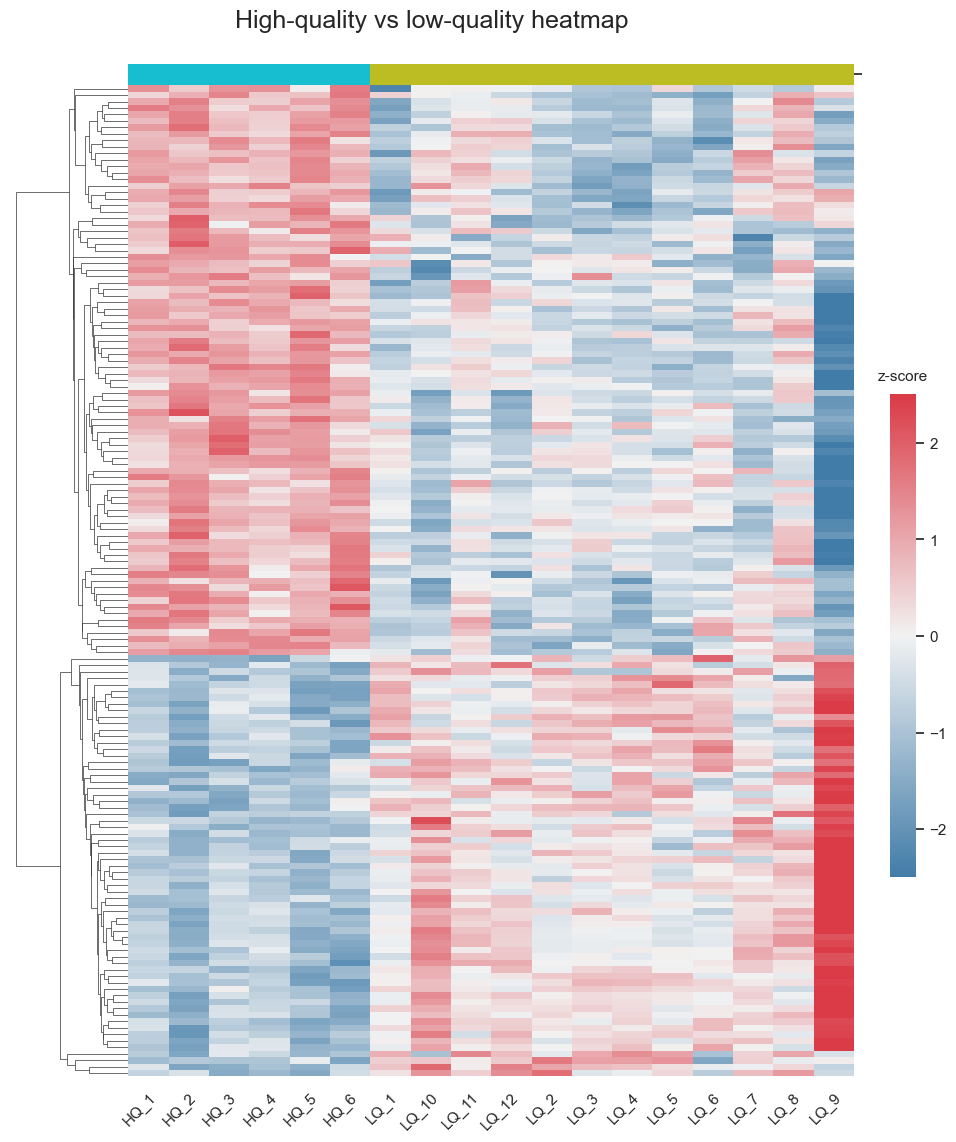

     display_name  log2FC_HQ_minus_LQ          pval      padj
3800        DARS2            0.298828  3.712947e-07  0.002605
6795         NUDC            0.277483  4.439750e-06  0.015572
4571       KLHDC4            0.294867  7.305535e-06  0.017083
3938       ASRGL1            0.670652  2.480015e-05  0.022316
3864        RBMS3           -0.609771  3.444535e-05  0.022316
(153, 18)


In [22]:
# Build the heatmap matrix from the selected proteins, apply heatmap-only cleanup, and render a publication-style clustermap (Fig. 5B)

plot_title = 'High-quality vs low-quality heatmap'
output_plot = './Fig 5B.png'
legend_fontsize = 18
legend_title_size = 18
x_tick_fontsize = 11
y_tick_fontsize = 8
plot_title_size = 18
colorbar_title_size = 11


selected_ids = sig_df['row_id'].tolist()
heat_df = sample_df.loc[selected_ids, sample_cols].copy()
name_map = sig_df.set_index('row_id')['display_name'].to_dict()
heat_df.index = [name_map[idx] for idx in heat_df.index]
heat_df = heat_df[~heat_df.index.duplicated(keep='first')]
min_non_na = int(np.ceil(0.7 * heat_df.shape[1]))
heat_df = heat_df.dropna(thresh=min_non_na)
heat_df = heat_df.apply(lambda row_vals: row_vals.fillna(row_vals.median()), axis=1)
heat_df = heat_df.dropna(axis=0, how='any')
heat_z = heat_df.sub(heat_df.mean(axis=1), axis=0).div(heat_df.std(axis=1), axis=0)
heat_z = heat_z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
ordered_cols = hq_cols + lq_cols
heat_z = heat_z[ordered_cols]
heat_z = heat_z.rename(columns={col_name: col_name.replace(' ', '_') for col_name in heat_z.columns})
sample_group = pd.Series(['high-quality' if col_name.startswith('HQ_') else 'low-quality' for col_name in heat_z.columns], index=heat_z.columns)
col_colors = sample_group.map(classif_colors)

sns.set_theme(style='white', font_scale=1.0)
g = sns.clustermap(heat_z, cmap=sns.diverging_palette(240, 10, as_cmap=True), center=0, vmin=-2.5, vmax=2.5, row_cluster=True, col_cluster=False, col_colors=col_colors, figsize=(8.8, 11.5), xticklabels=True, yticklabels=False, dendrogram_ratio=(0.14, 0.04), colors_ratio=0.02, cbar_pos=(1.02, 0.24, 0.03, 0.42), linewidths=0)
g.fig.suptitle(plot_title, y=0.995, fontsize=plot_title_size)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=x_tick_fontsize)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=y_tick_fontsize)
g.ax_col_dendrogram.set_visible(False)
g.ax_cbar.set_title('z-score', fontsize=colorbar_title_size, pad=10)
g.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(sig_df[['display_name', 'log2FC_HQ_minus_LQ', 'pval', 'padj']].head())
print(heat_z.shape)

In [23]:
# Compute the full non-imputed differential abundance table from expr_df already in memory and save both Excel and CSV outputs

sample_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6', 'LQ 1', 'LQ 10', 'LQ 11', 'LQ 12', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9']
hq_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6']
lq_cols = ['LQ 1', 'LQ 10', 'LQ 11', 'LQ 12', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9']
xlsx_name = 'proteomics_differential_abundance_full_no_imputation.xlsx'
csv_name = 'proteomics_differential_abundance_full_no_imputation.csv'

sample_df = expr_df[sample_cols].apply(pd.to_numeric, errors='coerce').copy()
gene_vals = expr_df['Genes'].fillna('').astype(str) if 'Genes' in expr_df.columns else pd.Series([''] * len(expr_df), index=expr_df.index)
protein_vals = expr_df['Protein.Ids'].fillna('').astype(str) if 'Protein.Ids' in expr_df.columns else pd.Series(expr_df.index.astype(str), index=expr_df.index)
feature_names = gene_vals.mask(gene_vals.str.strip().eq(''), protein_vals)

rows_out = []
for row_idx in tqdm(sample_df.index, desc='computing full statistics'):
    hq_vals = sample_df.loc[row_idx, hq_cols].astype(float)
    lq_vals = sample_df.loc[row_idx, lq_cols].astype(float)
    hq_non_na = hq_vals.notna().sum()
    lq_non_na = lq_vals.notna().sum()
    hq_mean = hq_vals.mean()
    lq_mean = lq_vals.mean()
    log2_fc = hq_mean - lq_mean
    if hq_non_na >= 2 and lq_non_na >= 2:
        pval_val = ttest_ind(hq_vals, lq_vals, equal_var=False, nan_policy='omit').pvalue
    else:
        pval_val = np.nan
    rows_out.append([row_idx, feature_names.loc[row_idx], protein_vals.loc[row_idx], hq_non_na, lq_non_na, hq_mean, lq_mean, log2_fc, pval_val])

stats_df = pd.DataFrame(rows_out, columns=['row_id', 'feature_name', 'protein_ids', 'hq_non_na', 'lq_non_na', 'hq_mean', 'lq_mean', 'log2FC_HQ_minus_LQ', 'pval'])
stats_df['display_name'] = stats_df['feature_name'].fillna('').astype(str)
stats_df['display_name'] = stats_df['display_name'].mask(stats_df['display_name'].str.strip().eq(''), stats_df['protein_ids'].fillna('').astype(str))
stats_df['padj'] = multipletests(stats_df['pval'].fillna(1.0), method='fdr_bh')[1]
stats_df['abs_log2FC'] = stats_df['log2FC_HQ_minus_LQ'].abs()
stats_df['passes_presence'] = (stats_df['hq_non_na'] >= 4) & (stats_df['lq_non_na'] >= 8)
stats_df['is_significant'] = stats_df['passes_presence'] & (stats_df['padj'] < 0.05) & (stats_df['abs_log2FC'] > 1.0)
stats_df = stats_df.sort_values(['padj', 'abs_log2FC'], ascending=[True, False])
stats_df.to_excel(xlsx_name, index=False)
stats_df.to_csv(csv_name, index=False)

print(stats_df.head())
print(stats_df['is_significant'].sum())
print(xlsx_name)
print(csv_name)

computing full statistics: 100%|██████████| 7096/7096 [00:18<00:00, 386.70it/s]


      row_id feature_name protein_ids  hq_non_na  lq_non_na    hq_mean  \
3800    3800        DARS2      Q6PI48          6         12  17.315954   
6795    6795         NUDC      Q9Y266          6         12  20.129283   
4571    4571       KLHDC4    Q8TBB5-3          6         12  15.007646   
2659    2659        GCNT1      Q02742          2         10  14.358704   
3938    3938       ASRGL1      Q7L266          6         12  17.303624   

        lq_mean  log2FC_HQ_minus_LQ          pval display_name      padj  \
3800  17.017126            0.298828  3.712947e-07        DARS2  0.002635   
6795  19.851801            0.277483  4.439750e-06         NUDC  0.015752   
4571  14.712779            0.294867  7.305535e-06       KLHDC4  0.017280   
2659  15.243325           -0.884621  2.451502e-05        GCNT1  0.022574   
3938  16.632972            0.670652  2.480015e-05       ASRGL1  0.022574   

      abs_log2FC  passes_presence  is_significant  
3800    0.298828             True           Fa

In [24]:
# Prepare for Volcano Plot
red_targets = ['SLC1A2', 'CAMKV', 'ERBB4']
blue_targets = ['SLC2A3', 'ITGA1', 'THBS1']

mask_red = stats_df['display_name'].isin(red_targets)
mask_blue = stats_df['display_name'].isin(blue_targets)
mask_hnrnpa3 = (stats_df['display_name'].eq('HNRNPA3')) & (stats_df['protein_ids'].eq('P51991-2'))
sel_df = stats_df[mask_red | mask_blue | mask_hnrnpa3][['display_name', 'protein_ids', 'log2FC_HQ_minus_LQ', 'padj']].copy()
print(sel_df)

font_names = sorted(set([f.name for f in fm.fontManager.ttflist]))
arial_like = [nm for nm in font_names if 'Arial' in nm or 'Liberation Sans' in nm or 'DejaVu Sans' in nm]
print(arial_like[:20])

     display_name protein_ids  log2FC_HQ_minus_LQ      padj
3200        ERBB4    Q15303-2            0.907068  0.025713
1078        THBS1      P07996           -1.479720  0.034267
2151      HNRNPA3    P51991-2            0.621867  0.038390
2285        ITGA1      P56199           -1.405236  0.040368
1201       SLC2A3      P11169           -1.361180  0.042836
4458        CAMKV      Q8NCB2            0.729405  0.044948
1904       SLC1A2    P43004-3            0.632518  0.046922
['Arial', 'Arial Rounded MT Bold', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'Liberation Sans', 'Liberation Sans Narrow']


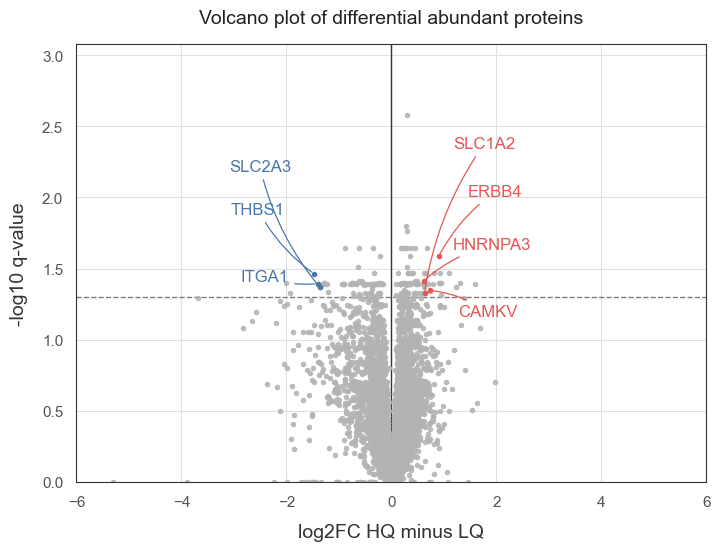

./Fig 5D.png


In [25]:
#Volcano Plot (Fig. 5D)

plot_df = stats_df.copy()
plot_df['neglog10_padj'] = -np.log10(plot_df['padj'].clip(lower=1e-300))
plot_df['highlight_group'] = 'other'
plot_df.loc[plot_df['display_name'].isin(['SLC1A2', 'CAMKV', 'ERBB4']), 'highlight_group'] = 'red'
plot_df.loc[(plot_df['display_name'].eq('HNRNPA3')) & (plot_df['protein_ids'].eq('P51991-2')), 'highlight_group'] = 'red'
plot_df.loc[plot_df['display_name'].isin(['SLC2A3', 'ITGA1', 'THBS1']), 'highlight_group'] = 'blue'

fig, ax = plt.subplots(figsize=(9, 6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.88, bottom=0.15)
ax.set_axisbelow(True)
ax.grid(True, color='#E0E0E0', linewidth=0.8)
ax.axvline(0, color='#333333', linewidth=1.0, zorder=1)
ax.axhline(-np.log10(0.05), color='#877877', linewidth=1.0, linestyle='--', zorder=1)

mask_other = plot_df['highlight_group'].eq('other')
mask_red = plot_df['highlight_group'].eq('red')
mask_blue = plot_df['highlight_group'].eq('blue')
ms_val = 4
ax.plot(plot_df.loc[mask_other, 'log2FC_HQ_minus_LQ'], plot_df.loc[mask_other, 'neglog10_padj'], 'o', ms=ms_val, color='#B3B3B3', mec='none', alpha=0.9, zorder=2)
ax.plot(plot_df.loc[mask_blue, 'log2FC_HQ_minus_LQ'], plot_df.loc[mask_blue, 'neglog10_padj'], 'o', ms=ms_val, color='#4C78A8', mec='none', zorder=4)
ax.plot(plot_df.loc[mask_red, 'log2FC_HQ_minus_LQ'], plot_df.loc[mask_red, 'neglog10_padj'], 'o', ms=ms_val, color='#E45756', mec='none', zorder=5)

label_df = plot_df.loc[mask_red | mask_blue, ['display_name', 'protein_ids', 'log2FC_HQ_minus_LQ', 'neglog10_padj', 'highlight_group']].copy()
label_df = label_df.sort_values(['highlight_group', 'neglog10_padj'], ascending=[True, False]).reset_index(drop=True)
placed = []
for idx, row_vals in label_df.iterrows():
    x_val = row_vals['log2FC_HQ_minus_LQ']
    y_val = row_vals['neglog10_padj']
    side = 1 if x_val >= 0 else -1
    dx = 0.55 * side
    candidate_offsets = [0.45, 0.25, 0.65, 0.05, 0.85, -0.15, 1.05, -0.35, 1.25]
    y_text = y_val + 0.25
    for off in candidate_offsets:
        cand_y = y_val + off
        overlaps = False
        for px, py in placed:
            if abs((x_val + dx) - px) < 0.9 and abs(cand_y - py) < 0.28:
                overlaps = True
                break
        if not overlaps:
            y_text = cand_y
            break
    placed.append((x_val + dx, y_text))
    ha_val = 'left' if side > 0 else 'right'
    color_val = '#E45756' if row_vals['highlight_group'] == 'red' else '#4C78A8'
    ax.annotate(row_vals['display_name'], xy=(x_val, y_val), xytext=(x_val + dx, y_text), textcoords='data',
                ha=ha_val, va='center', fontsize=12, color=color_val,
                arrowprops=dict(arrowstyle='-', color=color_val, lw=0.9, shrinkA=2, shrinkB=2,
                                connectionstyle='arc3,rad=0.12'), zorder=6)

ax.set_xlim(-6, 6)
ax.set_ylim(0, max(plot_df['neglog10_padj'].max() + 0.5, 2))
ax.set_title('Volcano plot of differential abundant proteins', fontsize=14, color='#222222', pad=15)
ax.set_xlabel('log2FC HQ minus LQ', fontsize=14, color='#333333', labelpad=10)
ax.set_ylabel('-log10 q-value', fontsize=14, color='#333333', labelpad=10)
ax.tick_params(axis='both', labelsize=11, colors='#555555')
for spine_name in ax.spines:
    ax.spines[spine_name].set_color('#333333')
    ax.spines[spine_name].set_linewidth(0.8)

out_file = './Fig 5D.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
plt.show()
print(out_file)

                  HQ 1       HQ 2       HQ 3       HQ 4       HQ 5       HQ 6  \
gene_symbol                                                                     
SLC2A3       15.930460  16.273049  16.841368  15.982691  16.133437  15.927609   
SLC1A2       14.112716  14.426645  14.239822  14.327279  14.830416  14.220749   
ERBB4        14.905857  15.213055  14.641854  14.597959  14.943637  15.203516   
CAMKV        14.673331  14.846504  15.211759  15.088755  15.423658  14.732475   

                  LQ 1       LQ 2       LQ 3       LQ 4       LQ 5       LQ 6  \
gene_symbol                                                                     
SLC2A3       17.231896  16.898885  17.563248  17.330155  16.721286  17.144847   
SLC1A2       13.392814  13.895963  13.931762  13.804867  13.956304  13.698357   
ERBB4        13.509923  14.202491  13.983127  13.739443  14.239643  13.634119   
CAMKV        13.982637  14.432581  14.221489  14.027984  14.466363  13.916029   

                  LQ 7    

100%|██████████| 4/4 [00:00<00:00, 497.72it/s]

  gene_symbol  n_HQ  n_LQ  median_HQ  median_LQ      pval      qval
0       CAMKV     6    12  14.967630  14.299045  0.001293  0.001293
1       ERBB4     6    12  14.924747  14.072133  0.000431  0.000862
2      SLC1A2     6    12  14.283551  13.764488  0.000754  0.001006
3      SLC2A3     6    12  16.058064  17.281026  0.000215  0.000862


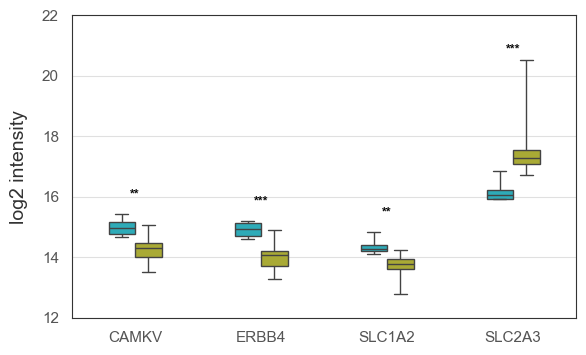

In [10]:
# Build the in-memory df and meta objects expected by the user's code, then compute stats and create the boxplot (Fig. 5E)

sample_cols = [col_val for col_val in expr_df.columns if str(col_val).startswith('HQ ') or str(col_val).startswith('LQ ')]
df = expr_df[['Genes'] + sample_cols].copy().rename(columns={'Genes': 'gene_symbol'})
df = df.dropna(subset=['gene_symbol']).drop_duplicates(subset=['gene_symbol']).set_index('gene_symbol')
meta = pd.DataFrame({'Sample': sample_cols})
meta['Group'] = meta['Sample'].str.extract('^(HQ|LQ)')

selected_proteins = ['CAMKV', 'ERBB4', 'SLC1A2', 'SLC2A3']
classif_colors = {'HQ': '#17becf', 'LQ': '#bcbd22'}
Y_MIN, Y_MAX = 12, 22

df_sub = df.loc[df.index.intersection(selected_proteins)].copy()
print(df_sub.head())

df_long = df_sub.reset_index().melt(id_vars='gene_symbol', var_name='Sample', value_name='Intensity')
df_long = df_long.merge(meta[['Sample', 'Group']], on='Sample', how='left')
df_long = df_long[df_long['Group'].isin(['HQ', 'LQ'])].copy()
df_long['Group'] = pd.Categorical(df_long['Group'], categories=['HQ', 'LQ'], ordered=True)
df_long['gene_symbol'] = pd.Categorical(df_long['gene_symbol'], categories=selected_proteins, ordered=True)

records = []
for prot_name, grp_df in tqdm(df_long.groupby('gene_symbol', observed=True)):
    hq_vals = grp_df.loc[grp_df['Group'] == 'HQ', 'Intensity'].dropna()
    lq_vals = grp_df.loc[grp_df['Group'] == 'LQ', 'Intensity'].dropna()
    pval = np.nan
    if len(hq_vals) >= 3 and len(lq_vals) >= 3:
        try:
            _, pval = mannwhitneyu(hq_vals, lq_vals, alternative='two-sided')
        except ValueError:
            pval = np.nan
    records.append({'gene_symbol': prot_name, 'n_HQ': len(hq_vals), 'n_LQ': len(lq_vals), 'median_HQ': hq_vals.median(), 'median_LQ': lq_vals.median(), 'pval': pval})
stats_df = pd.DataFrame(records)
mask = stats_df['pval'].notna()
if mask.sum() > 0:
    stats_df.loc[mask, 'qval'] = multipletests(stats_df.loc[mask, 'pval'], method='fdr_bh')[1]
else:
    stats_df['qval'] = np.nan

print(stats_df)
stats_df.to_csv('selected_proteins_HQ_vs_LQ_stats.csv', index=False)

def q_to_symbol(q_val):
    if pd.isna(q_val):
        return ''
    if q_val < 0.001:
        return '***'
    if q_val < 0.01:
        return '**'
    if q_val < 0.05:
        return '*'
    return ''

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(7.2, 4.2))
plt.subplots_adjust(left=0.12, right=0.82, top=0.88, bottom=0.16)
sns.boxplot(data=df_long, x='gene_symbol', y='Intensity', hue='Group', order=selected_proteins, hue_order=['HQ', 'LQ'], palette=classif_colors, width=0.42, dodge=True, whis=[0, 100], showcaps=True, fliersize=2.5, linewidth=1.0, ax=ax, legend=False)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('')
ax.set_ylabel('log2 intensity', fontsize=14, color='#333333', labelpad=10)
ax.tick_params(axis='x', labelsize=11, colors='#555555')
ax.tick_params(axis='y', labelsize=11, colors='#555555')
ax.set_axisbelow(True)
ax.grid(axis='y', color='#E0E0E0', linewidth=0.8)
ax.grid(axis='x', visible=False)
for spine_name in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine_name].set_color('#333333')
    ax.spines[spine_name].set_linewidth(0.8)
for idx_val, prot_name in enumerate(selected_proteins):
    vals = df_long[df_long['gene_symbol'] == prot_name]['Intensity'].dropna()
    row_df = stats_df[stats_df['gene_symbol'] == prot_name]
    qval = row_df['qval'].iloc[0] if len(row_df) > 0 else np.nan
    sym = q_to_symbol(qval)
    if sym and len(vals) > 0:
        yoff = 0.18 if prot_name == 'SLC2A3' else 0.45
        y_pos = min(Y_MAX - 0.3, float(np.nanmax(vals)) + yoff)
        ax.text(idx_val, y_pos, sym, ha='center', va='bottom', fontsize=9, weight='bold', color='black')
plt.savefig('./Fig 5E.png', dpi=400, bbox_inches='tight')
plt.show()

In [11]:
# Inspect shape and sample columns before PCA-based dispersion analysis

proteomics_df = expr_df.copy()
sample_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6', 'LQ 1', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9', 'LQ 10', 'LQ 11', 'LQ 12']
protein_mat = proteomics_df[sample_cols].apply(pd.to_numeric, errors='coerce')
print(proteomics_df.head())
print(protein_mat.shape)
print(sample_cols)

       Genes Protein.Ids       HQ 1       HQ 2       HQ 3       HQ 4  \
0  IGKV2D-24  A0A075B6R9  15.469740  15.605546  15.871797  16.223689   
1     TRBV18  A0A087X0M5  14.018548  13.719859  14.996434  15.196337   
2      RBM47    A0AV96-2  16.645039  17.192717  16.464375  16.060257   
3      IFT56      A0AVF1  14.486131  14.416633  14.869266  14.594185   
4       UBA6      A0AVT1  16.470419  16.936856  16.731226  16.569620   

        HQ 5       HQ 6       LQ 1       LQ 2       LQ 3       LQ 4  \
0  16.298496  15.688362  16.007540  16.033236  16.145230  16.140013   
1  15.007089  13.414025  14.973182  14.818323  15.131664  15.237176   
2  15.427513  17.282229  16.944746  16.853176  16.812804  16.929894   
3  14.663041  14.434342  14.547919  14.479218  14.505334  14.550176   
4  16.597338  16.799560  16.668026  16.747904  16.630694  16.604197   

        LQ 5       LQ 6       LQ 7       LQ 8       LQ 9      LQ 10  \
0  15.611595  15.097575  15.512410  16.164856  14.729440  15.727059  

In [12]:
# Recreate the PCA used for the proteomics samples, then compute observed pairwise dispersions and the permutation distributions needed for the paper figure

sample_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6', 'LQ 1', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9', 'LQ 10', 'LQ 11', 'LQ 12']
hq_cols = ['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6']
lq_cols = ['LQ 1', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9', 'LQ 10', 'LQ 11', 'LQ 12']

protein_vals = proteomics_df[sample_cols].apply(pd.to_numeric, errors='coerce').copy()
valid_rows = protein_vals.notna().sum(axis=1) > 0
protein_vals = protein_vals.loc[valid_rows]
protein_vals = protein_vals.apply(lambda row_vals: row_vals.fillna(row_vals.median()), axis=1)
protein_centered = protein_vals.sub(protein_vals.median(axis=1), axis=0)
pca_input = protein_centered.T.copy()

pca_model = PCA(n_components=2)
pca_scores = pca_model.fit_transform(pca_input)
pca_df = pd.DataFrame({'Sample': pca_input.index, 'PC1': pca_scores[:, 0], 'PC2': pca_scores[:, 1]})
pca_df['Group'] = np.where(pca_df['Sample'].str.startswith('HQ'), 'HQ', 'LQ')


def mean_pairwise_dist(coords_df):
    return float(pdist(coords_df[['PC1', 'PC2']].to_numpy(), metric='euclidean').mean())

hq_obs = mean_pairwise_dist(pca_df[pca_df['Group'] == 'HQ'])
lq_obs = mean_pairwise_dist(pca_df[pca_df['Group'] == 'LQ'])

rng_obj = np.random.default_rng(42)
lq_names = pca_df.loc[pca_df['Group'] == 'LQ', 'Sample'].to_numpy()
subsample_vals = []
for idx_val in tqdm(range(1000), desc='LQ subsampling'):
    picked = rng_obj.choice(lq_names, size=6, replace=False)
    picked_df = pca_df[pca_df['Sample'].isin(picked)]
    subsample_vals.append(mean_pairwise_dist(picked_df))
subsample_arr = np.array(subsample_vals)

all_names = pca_df['Sample'].to_numpy()
obs_diff = lq_obs - hq_obs
perm_diffs = []
for idx_val in tqdm(range(10000), desc='Permutation test'):
    permuted = rng_obj.permutation(all_names)
    grp_a = pca_df[pca_df['Sample'].isin(permuted[:6])]
    grp_b = pca_df[pca_df['Sample'].isin(permuted[6:12])]
    diff_val = mean_pairwise_dist(grp_a) - mean_pairwise_dist(grp_b)
    perm_diffs.append(diff_val)
perm_arr = np.array(perm_diffs)
p_emp = (np.sum(np.abs(perm_arr) >= abs(obs_diff)) + 1) / (len(perm_arr) + 1)

sub_median = float(np.median(subsample_arr))
sub_q1 = float(np.quantile(subsample_arr, 0.25))
sub_q3 = float(np.quantile(subsample_arr, 0.75))

print(pca_df)
print(hq_obs)
print(lq_obs)
print(sub_median)
print(sub_q1)
print(sub_q3)
print(p_emp)
print(pca_model.explained_variance_ratio_)

Permutation test: 100%|██████████| 10000/10000 [00:10<00:00, 934.97it/s]

   Sample        PC1        PC2 Group
0    HQ 1  -1.674446 -13.154106    HQ
1    HQ 2 -17.919659 -17.252335    HQ
2    HQ 3 -12.442218  -2.176546    HQ
3    HQ 4  -6.327378  -6.979007    HQ
4    HQ 5   0.487289 -23.879342    HQ
5    HQ 6 -16.078430 -13.890363    HQ
6    LQ 1 -18.934506  14.843110    LQ
7    LQ 2 -21.396268  12.299560    LQ
8    LQ 3 -17.725812  15.135605    LQ
9    LQ 4 -19.555863  15.337709    LQ
10   LQ 5 -20.429443  10.791183    LQ
11   LQ 6 -16.932571  17.297263    LQ
12   LQ 7  30.056164 -11.174215    LQ
13   LQ 8   8.968919  -6.385387    LQ
14   LQ 9  63.205526  27.228538    LQ
15  LQ 10  38.762876  -2.731774    LQ
16  LQ 11  15.710093  -6.639705    LQ
17  LQ 12  12.225727  -8.670188    LQ
14.33163328433078
35.97564055020476
36.97962124775006
29.932847851563317
44.25223099019477
0.1227877212278772
[0.46114799 0.16688396]


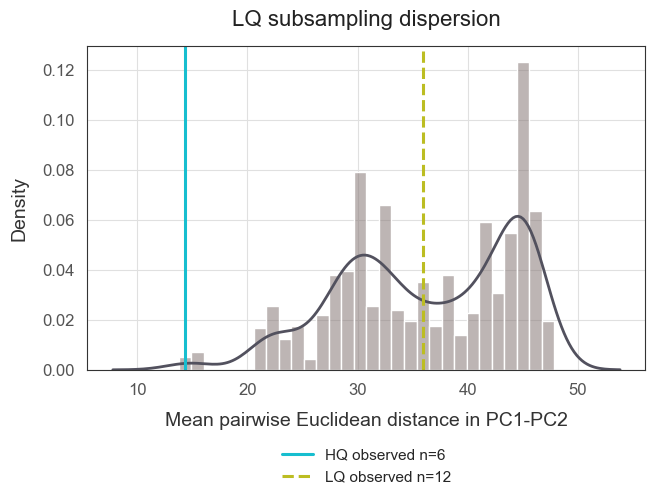

./Supp Fig. S3.png


In [13]:
# LQ Subsampling Dispersion (Panel B is Supp Fig. S3; Panel A is extra graph, won't be published)

sns.set_style('whitegrid')

panel_colors = {'HQ': '#766CDB', 'LQ': '#DA847C'}

def add_confidence_ellipse(ax_obj, x_vals, y_vals, edge_color):
    coords = np.column_stack([x_vals, y_vals])
    if coords.shape[0] < 3:
        return
    cov_mat = np.cov(coords, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_mat)
    order_idx = eigvals.argsort()[::-1]
    eigvals = eigvals[order_idx]
    eigvecs = eigvecs[:, order_idx]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    scale_val = np.sqrt(chi2.ppf(0.95, df=2))
    width = 2 * scale_val * np.sqrt(max(eigvals[0], 0))
    height = 2 * scale_val * np.sqrt(max(eigvals[1], 0))
    ellipse = Ellipse((np.mean(x_vals), np.mean(y_vals)), width=width, height=height, angle=angle, facecolor='none', edgecolor=edge_color, linewidth=1.5)
    ax_obj.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(7.2, 4.2))

sns.histplot(subsample_arr, bins=30, color='#877877', edgecolor='white', alpha=0.55, stat='density', ax=ax)
sns.kdeplot(subsample_arr, color='#52515E', linewidth=2, ax=ax)
ax.axvline(hq_obs, color='#17becf', linewidth=2.2, linestyle='-', label='HQ observed n=6')
ax.axvline(lq_obs, color='#bcbd22', linewidth=2.2, linestyle='--', label='LQ observed n=12')
ax.set_title('LQ subsampling dispersion', fontsize=16, color='#222222', pad=15)
ax.set_xlabel('Mean pairwise Euclidean distance in PC1-PC2', fontsize=14, color='#333333', labelpad=10)
ax.set_ylabel('Density', fontsize=14, color='#333333', labelpad=10)
ax.tick_params(axis='both', labelsize=12, colors='#555555')
ax.grid(color='#E0E0E0', linewidth=0.8)
ax.set_axisbelow(True)
for spine_name in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine_name].set_color('#333333')
    ax.spines[spine_name].set_linewidth(0.8)
ax.legend(frameon=False, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=1)

updated_name = './Supp Fig. S3.png'
plt.savefig(updated_name, dpi=400, bbox_inches='tight')
plt.show()
print(updated_name)

In [14]:
# Clean the uploaded proteomics table, compute HQ vs LQ statistics, and show the key outputs
sample_cols_hq = [col_name for col_name in expr_df.columns if str(col_name).startswith('HQ ')]
sample_cols_lq = [col_name for col_name in expr_df.columns if str(col_name).startswith('LQ ')]
all_sample_cols = sample_cols_hq + sample_cols_lq

proteomics_df = expr_df.copy()
proteomics_df['Genes'] = proteomics_df['Genes'].astype(str).str.split(';').str[0].str.strip()
proteomics_df = proteomics_df.replace([np.inf, -np.inf], np.nan)
proteomics_df = proteomics_df.dropna(subset=['Genes'])
proteomics_df = proteomics_df[proteomics_df['Genes'] != ''].copy()
proteomics_df['missing_frac'] = proteomics_df[all_sample_cols].isna().mean(axis=1)
proteomics_df = proteomics_df[proteomics_df['missing_frac'] <= 0.5].copy()

rows_out = []
for _, row_vals in tqdm(proteomics_df.iterrows(), total=len(proteomics_df)):
    hq_vals = pd.to_numeric(row_vals[sample_cols_hq], errors='coerce').values.astype(float)
    lq_vals = pd.to_numeric(row_vals[sample_cols_lq], errors='coerce').values.astype(float)
    mean_hq = np.nanmean(hq_vals)
    mean_lq = np.nanmean(lq_vals)
    log2_fc = mean_hq - mean_lq
    test_res = stats.ttest_ind(hq_vals, lq_vals, equal_var=False, nan_policy='omit')
    rows_out.append([row_vals['Genes'], row_vals['Protein.Ids'], mean_hq, mean_lq, log2_fc, test_res.statistic, test_res.pvalue])

stats_df = pd.DataFrame(rows_out, columns=['Genes', 'Protein.Ids', 'mean_HQ', 'mean_LQ', 'log2FC_HQ_minus_LQ', 't_stat', 'p_value'])
stats_df = stats_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['t_stat', 'p_value']).copy()
stats_df['FDR'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]
stats_df['abs_t'] = stats_df['t_stat'].abs()
stats_df = stats_df.sort_values(['abs_t', 'Genes'], ascending=[False, True])
stats_df = stats_df.drop_duplicates(subset='Genes', keep='first').copy()
stats_df = stats_df.sort_values('t_stat', ascending=False).reset_index(drop=True)

rank_df = stats_df[['Genes', 't_stat']].copy()
rank_df.columns = ['gene', 'score']

print(sample_cols_hq)
print(sample_cols_lq)
print(stats_df.head())
print(rank_df.head())

 12%|█▏        | 817/7011 [00:01<00:14, 427.33it/s]C:\Users\Windows\AppData\Local\Temp\ipykernel_18388\183911920.py:18: RuntimeWarning: Mean of empty slice
  mean_hq = np.nanmean(hq_vals)
E:\Conda3\envs\AI_Project\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
 88%|████████▊ | 6193/7011 [00:15<00:01, 422.26it/s]C:\Users\Windows\AppData\Local\Temp\ipykernel_18388\183911920.py:18: RuntimeWarning: Mean of empty slice
  mean_hq = np.nanmean(hq_vals)
E:\Conda3\envs\AI_Project\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
100%|██████████| 7011/7011 [00:17<00:00, 411.81it/s]

['HQ 1', 'HQ 2', 'HQ 3', 'HQ 4', 'HQ 5', 'HQ 6']
['LQ 1', 'LQ 2', 'LQ 3', 'LQ 4', 'LQ 5', 'LQ 6', 'LQ 7', 'LQ 8', 'LQ 9', 'LQ 10', 'LQ 11', 'LQ 12']
    Genes Protein.Ids    mean_HQ    mean_LQ  log2FC_HQ_minus_LQ    t_stat  \
0   DARS2      Q6PI48  17.315954  17.017126            0.298828  8.362379   
1    NUDC      Q9Y266  20.129283  19.851801            0.277483  7.538284   
2    YBX1      P67809  20.670536  20.454214            0.216321  6.712162   
3  KLHDC4    Q8TBB5-3  15.007646  14.712779            0.294867  6.508318   
4  ASRGL1      Q7L266  17.303624  16.632972            0.670652  6.216494   

        p_value       FDR     abs_t  
0  3.712947e-07  0.002599  8.362379  
1  4.439750e-06  0.015539  7.538284  
2  2.992285e-05  0.022268  6.712162  
3  7.305535e-06  0.017046  6.508318  
4  2.480015e-05  0.022268  6.216494  
     gene     score
0   DARS2  8.362379
1    NUDC  7.538284
2    YBX1  6.712162
3  KLHDC4  6.508318
4  ASRGL1  6.216494


In [15]:
# Run preranked GSEA if gseapy is available, then save outputs and print the most enriched results

gene_sets_list = ['GO_Biological_Process_2023', 'Reactome_2022', 'KEGG_2021_Human']
gsea_results = {}

for gene_set_name in tqdm(gene_sets_list):
    prerank_res = gp.prerank(
        rnk=rank_df,
        gene_sets=gene_set_name,
        min_size=10,
        max_size=500,
        permutation_num=1000,
        seed=42,
        outdir=None,
        verbose=False
    )
    result_df = prerank_res.res2d.copy()
    result_df['library'] = gene_set_name
    gsea_results[gene_set_name] = result_df

combined_gsea_df = pd.concat(gsea_results.values(), ignore_index=True)
combined_gsea_df['NES'] = pd.to_numeric(combined_gsea_df['NES'], errors='coerce')
combined_gsea_df['FDR q-val'] = pd.to_numeric(combined_gsea_df['FDR q-val'], errors='coerce')
combined_gsea_df = combined_gsea_df.sort_values('FDR q-val', ascending=True).reset_index(drop=True)

hq_enriched_df = combined_gsea_df[(combined_gsea_df['NES'] > 0) & (combined_gsea_df['FDR q-val'] < 0.05)].sort_values(['FDR q-val', 'NES'], ascending=[True, False]).reset_index(drop=True)
lq_enriched_df = combined_gsea_df[(combined_gsea_df['NES'] < 0) & (combined_gsea_df['FDR q-val'] < 0.05)].sort_values(['FDR q-val', 'NES'], ascending=[True, True]).reset_index(drop=True)

combined_gsea_df.to_csv('gsea_combined_results.csv', index=False)
hq_enriched_df.to_csv('gsea_HQ_enriched_FDR_lt_0.05.csv', index=False)
lq_enriched_df.to_csv('gsea_LQ_enriched_FDR_lt_0.05.csv', index=False)
stats_df.to_csv('HQ_vs_LQ_ranked_proteomics_statistics.csv', index=False)
rank_df.to_csv('HQ_vs_LQ_preranked_gene_list.csv', index=False)

with pd.ExcelWriter('gsea_results_and_rankings.xlsx', engine='openpyxl') as writer:
    combined_gsea_df.to_excel(writer, sheet_name='all_gsea_results', index=False)
    hq_enriched_df.to_excel(writer, sheet_name='HQ_enriched_FDR_lt_0_05', index=False)
    lq_enriched_df.to_excel(writer, sheet_name='LQ_enriched_FDR_lt_0_05', index=False)
    stats_df.to_excel(writer, sheet_name='protein_level_statistics', index=False)
    rank_df.to_excel(writer, sheet_name='preranked_gene_list', index=False)

print(combined_gsea_df.head(20))
print('gsea_results_and_rankings.xlsx')

100%|██████████| 3/3 [00:40<00:00, 13.48s/it]


       Name                                               Term        ES  \
0   prerank  RNA Splicing, Via Transesterification Reaction...  0.541283   
1   prerank                 Cell Cycle Checkpoints R-HSA-69620  0.502518   
2   prerank                        DNA Replication R-HSA-69306  0.553874   
3   prerank                           Cell Cycle R-HSA-1640170  0.456874   
4   prerank                       Synthesis Of DNA R-HSA-69239  0.557361   
5   prerank  Post-translational Protein Phosphorylation R-H... -0.581813   
6   prerank  Regulation Of IGF Transport And Uptake By IGFB... -0.579435   
7   prerank  Processing Of Capped Intron-Containing Pre-mRN...   0.51034   
8   prerank                      Cilium Assembly R-HSA-5617833  0.584164   
9   prerank    Extracellular Matrix Organization R-HSA-1474244 -0.558284   
10  prerank          mRNA Splicing - Major Pathway R-HSA-72163  0.568048   
11  prerank                          mRNA Splicing R-HSA-72172  0.568048   
12  prerank 

100%|██████████| 6/6 [00:00<00:00, 129.06it/s]


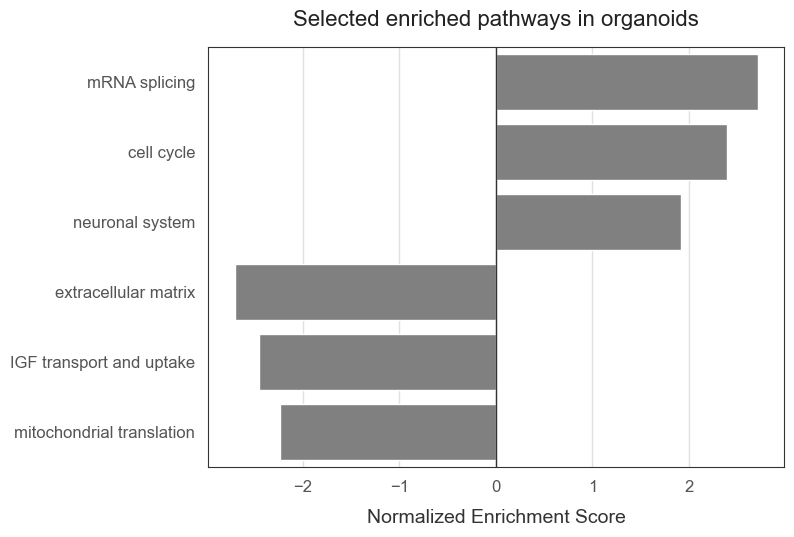

In [18]:
# Bar plot for the selected GSEA results (Fig. 5C)

plot_gsea_df = combined_gsea_df.copy()
plot_gsea_df['NES'] = pd.to_numeric(plot_gsea_df['NES'], errors='coerce')
plot_gsea_df['FDR q-val'] = pd.to_numeric(plot_gsea_df['FDR q-val'], errors='coerce')
plot_gsea_df = plot_gsea_df.dropna(subset=['NES', 'FDR q-val']).copy()

term_requests = [
    {'Group': 'HQ', 'Requested': 'mRNA splicing', 'Pattern': 'mRNA Splicing'},
    {'Group': 'HQ', 'Requested': 'cell cycle', 'Pattern': 'Cell Cycle'},
    {'Group': 'HQ', 'Requested': 'neuronal system', 'Pattern': 'Neuronal System'},
    {'Group': 'LQ', 'Requested': 'extracellular matrix', 'Pattern': 'Extracellular Matrix'},
    {'Group': 'LQ', 'Requested': 'IGF transport and uptake', 'Pattern': 'Regulation Of IGF Transport And Uptake'},
    {'Group': 'LQ', 'Requested': 'mitochondrial translation', 'Pattern': 'Mitochondrial Translation'}
]

selected_rows = []
for req_vals in tqdm(term_requests):
    if req_vals['Group'] == 'HQ':
        subset_df = plot_gsea_df[plot_gsea_df['NES'] > 0].copy()
        matched_df = subset_df[subset_df['Term'].astype(str).str.contains(req_vals['Pattern'], case=False, na=False)].copy()
        matched_df = matched_df.sort_values(['FDR q-val', 'NES'], ascending=[True, False])
    else:
        subset_df = plot_gsea_df[plot_gsea_df['NES'] < 0].copy()
        matched_df = subset_df[subset_df['Term'].astype(str).str.contains(req_vals['Pattern'], case=False, na=False)].copy()
        matched_df = matched_df.sort_values(['FDR q-val', 'NES'], ascending=[True, True])
    if len(matched_df) > 0:
        top_row = matched_df.iloc[0].copy()
        top_row['Requested'] = req_vals['Requested']
        top_row['Group'] = req_vals['Group']
        selected_rows.append(top_row)

selected_terms_df = pd.DataFrame(selected_rows)
plot_order = ['mRNA splicing', 'cell cycle', 'neuronal system', 'extracellular matrix', 'IGF transport and uptake', 'mitochondrial translation']
selected_terms_df['Display'] = selected_terms_df['Requested']
selected_terms_df['Display'] = pd.Categorical(selected_terms_df['Display'], categories=plot_order, ordered=True)
selected_terms_df = selected_terms_df.sort_values('Display').copy()
selected_terms_df.to_csv('selected_6_terms_gsea_values_clean_labels.csv', index=False)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.28, right=0.92, top=0.85, bottom=0.15)
sns.barplot(data=selected_terms_df, x='NES', y='Display', color='grey', ax=ax)
ax.axvline(0, color='#333333', linewidth=1)
ax.set_title('Selected enriched pathways in organoids', fontsize=16, color='#222222', pad=15)
ax.set_xlabel('Normalized Enrichment Score', fontsize=14, color='#333333', labelpad=10)
ax.set_ylabel('', fontsize=14, color='#333333', labelpad=10)
ax.tick_params(axis='both', labelsize=12, colors='#555555')
ax.set_axisbelow(True)
ax.grid(True, axis='x', color='#E0E0E0')
ax.grid(False, axis='y')
for spine_name in ax.spines:
    ax.spines[spine_name].set_visible(True)
    ax.spines[spine_name].set_color('#333333')
    ax.spines[spine_name].set_linewidth(0.8)
plt.savefig('./Fig 5C.png', dpi=300, bbox_inches='tight')
plt.show()

selected_terms_df.to_csv('selected_6_terms_gsea_values_clean_labels.csv', index=False)

In [17]:
import session_info
session_info.show()